### Graph introduction:
1. Basic terminology
2. Graph representatios
   1. Adjacency matrix
   2. Adjacency list

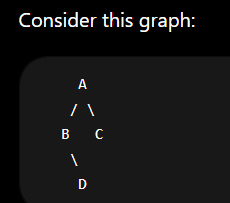

### Graphs Traversal:
1. DFS
2. BFS


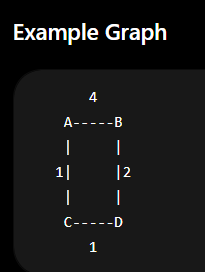

```
Recommended Order
1971 – Find if Path Exists in Graph
733 – Flood Fill
841 – Keys and Rooms
200 – Number of Islands
695 – Max Area of Island

### Common Pattern to Remember
Most graph/grid DFS problems follow this template:
```
def dfs(r, c):
    if invalid:
        return

    mark_visited()

    dfs(r+1, c)
    dfs(r-1, c)
    dfs(r, c+1)
    dfs(r, c-1)

### Adjacency list:

In [2]:
edges = [('A','B'),('A','C'),('B','D')]

In [4]:
graph = {}
for u,v in edges:
    if u not in graph:
        graph[u] = [] 
    if v not in graph:
        graph[v] = []
    graph[u].append(v)
    graph[v].append(u)
print(graph)
    

{'A': ['B', 'C'], 'B': ['A', 'D'], 'C': ['A'], 'D': ['B']}


### Depth First Search:

In [7]:
visited = set()
def dfs(node):
    visited.add(node)
    print(node,end=" ")
    for neighbors in graph[node]:
        if neighbors not in visited:
            dfs(neighbors)
dfs('A')

A B D C 

### Breadth First Search:

In [9]:
visited = set()
def bfs(node):
    queue = [node]
    visited.add(node)
    while queue:
        p = queue.pop(0)
        print(p,end=" ")
        for nei in graph[p]:
            if nei not in visited:
                visited.add(nei)
                queue.append(nei)                

bfs('A')

A B C D 

## Leetcode problems:

### 841. Keys and Rooms

In [11]:
from typing import List
class Solution:
    def canVisitAllRooms(self, rooms: List[List[int]]) -> bool:
        visited = set()
        def dfs(node):
            visited.add(node)
            for neighbors in rooms[node]:
                if neighbors not in visited:
                    dfs(neighbors)
        dfs(0)
        return len(visited) == len(rooms)

### 1971. Find if Path Exists in Graph

In [13]:
class Solution:
    def validPath(self, n: int, edges: List[List[int]], source: int, destination: int) -> bool:
        d = {i:[] for i in range(n)}
        for u,v in edges:
            d[u].append(v)
            d[v].append(u)
        visited = set()
        def dfs(node):
            visited.add(node)
            if node == destination:
                return True
            for neighbors in d[node]:
                if neighbors not in visited:
                    if dfs(neighbors):
                        return True
            return False
        return dfs(source)
        

### 733. Flood Fill

In [14]:
class Solution:
    def floodFill(self, image: List[List[int]], sr: int, sc: int, color: int) -> List[List[int]]:
        old = image[sr][sc]
        if old == color:
            return image
        def dfs(r, c):
            if r < 0 or c < 0 or r >= len(image) or c >= len(image[0]):
                return
            if image[r][c] != old:
                return
            image[r][c] = color
            dfs(r+1, c)
            dfs(r-1, c)
            dfs(r, c+1)
            dfs(r, c-1)
        dfs(sr, sc)
        return image
            